In [2]:
# %load_ext autoreload
# %autoreload 2

import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data.loader import DataLoader
loader = DataLoader()

ratings = loader.load_ratings()
movies = loader.load_movies()
df = loader.load_merged_data()

df[['user_id', 'title', 'rating', 'genres_text']].head()

,user_id,title,rating,genres_text
0,196,Kolya (1996),3,Comedy
1,186,L.A. Confidential (1997),3,Crime Film-Noir Mystery Thriller
2,22,Heavyweights (1994),1,Children Comedy
3,244,Legends of the Fall (1994),2,Drama Romance War Western
4,166,Jackie Brown (1997),1,Crime Drama


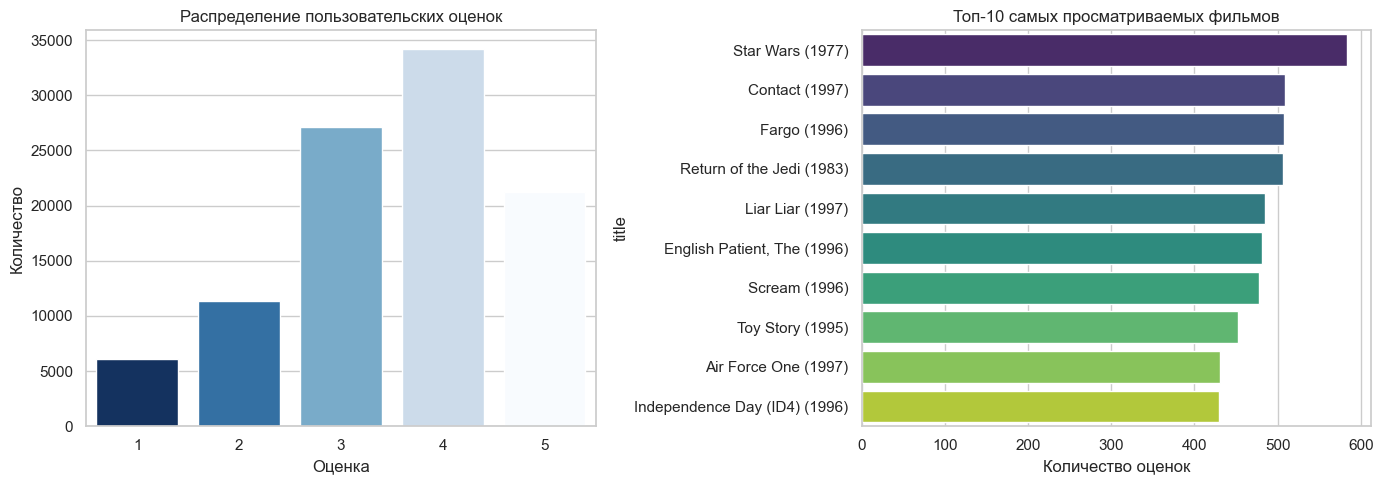

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Распределение оценок (исправлено с hue)
sns.countplot(
    ax=axes[0],
    x='rating',
    hue='rating',
    data=ratings,
    palette='Blues_r',
    legend=False
)
axes[0].set_title('Распределение пользовательских оценок')
axes[0].set_xlabel('Оценка')
axes[0].set_ylabel('Количество')

# 2. Топ-10 самых популярных фильмов (исправлено с hue)
top_movies = df['title'].value_counts().head(10)
sns.barplot(
    ax=axes[1],
    x=top_movies.values,
    y=top_movies.index,
    hue=top_movies.index,
    palette='viridis',
    legend=False
)
axes[1].set_title('Топ-10 самых просматриваемых фильмов')
axes[1].set_xlabel('Количество оценок')

plt.tight_layout()
plt.show()

In [13]:
from src.data.loader import DataLoader
from src.models.content_based import ContentBasedRecommender

# 1. Добавляем скобки () для создания экземпляра
loader = DataLoader()

# 2. Загружаем фильмы
movies = loader.load_movies()

# 3. Инициализируем и обучаем Content-Based модель
cb_model = ContentBasedRecommender()
cb_model.fit(movies)

# 4. Проверяем рекомендации для Star Wars (movie_id = 50)
target_movie = movies[movies['movie_id'] == 50].iloc[0]
print(f"Целевой фильм: {target_movie['title']} | Жанры: {target_movie['genres_text']}\n")

recs = cb_model.recommend_similar_movies(movie_id=50, top_n=5)
recs

Целевой фильм: Star Wars (1977) | Жанры: Action Adventure Romance Sci-Fi War



,movie_id,title,genres_text,similarity_score
180,181,Return of the Jedi (1983),Action Adventure Romance Sci-Fi War,1.000000
171,172,"Empire Strikes Back, The (1980)",Action Adventure Drama Romance Sci-Fi War,0.978268
270,271,Starship Troopers (1997),Action Adventure Sci-Fi War,0.941994
120,121,Independence Day (ID4) (1996),Action Sci-Fi War,0.850581
234,235,Mars Attacks! (1996),Action Comedy Sci-Fi War,0.815144


In [4]:
import sys
from pathlib import Path

# Добавляем корень проекта в sys.path
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data.loader import DataLoader
from src.models.collaborative import CollaborativeRecommender

# 1. Загружаем данные
loader = DataLoader()
ratings = loader.load_ratings()
movies = loader.load_movies()

# 2. Обучаем SVD модель
cf_model = CollaborativeRecommender(n_factors=20)
cf_model.fit(ratings)

# 3. Генерируем топ-5 рекомендаций для пользователя #1
user_id = 2
recs_cf = cf_model.recommend_for_user(
    user_id=user_id,
    ratings_df=ratings,
    movies_df=movies,
    top_n=5
)

print(f"Персональные рекомендации для User #{user_id}:")
recs_cf

Персональные рекомендации для User #2:


,movie_id,title,genres_text,predicted_rating
123,124,Lone Star (1996),Drama Mystery,2.784027
8,9,Dead Man Walking (1995),Drama,2.534156
136,137,Big Night (1996),Drama,2.350128
180,181,Return of the Jedi (1983),Action Adventure Romance Sci-Fi War,2.345703
514,515,"Boot, Das (1981)",Action Drama War,2.113725
